Machine Learning

<h1>Aula 2 - Conhecendo e Tratando os seus Dados</h1>

# Objetivos da Aula

Nesta aula, você vai aprender a dar os primeiros passos com dataframes, que são estruturas de dados muito utilizadas em Python para análise de tabelas e criação de modelos de Machine Learning.

Ao final desta aula, você será capaz de:

1) Importar e visualizar os seus dados, a partir do Google Drive ou de um link da internet, como o GitHub;

2) Aplicar filtros e selecionar colunas específicas, para focar em partes importantes da base;

3) Tratar problemas comuns nos dados, como:

- Linhas duplicadas;
- Valores ausentes;
- Tipos de variáveis inconsistentes;
- Outliers

4) Gerar estatísticas descritivas para entender as variáveis;

5) Criar visualizações gráficas básicas, boxplots e gráficos de contagem;

6) Salvar os dados tratados, garantindo que o trabalho realizado não seja perdido.

---

# Instalação e Importação das Bibliotecas

In [1]:
#manipulação de dados
import pandas as pd
import numpy as np

#visualização de dados
import seaborn as sns
import matplotlib.pyplot as plt
import plotly.express as px

# 1) Importação dos Dados

<h3> Relembrando...

→ Para manipularmos dados, valores, tabelas, textos... precisamos associá-los a uma variável utilizando o sinal `=`.

**→ Cuidado com a sintaxe python:**  
- O sinal de igualdade matemática é `==`;
- O sinal de associação é `=`.

→ Se quisermos escrever um comentário no código, utilizamos o `#`

---

<h3> Importando os dados

→ Existem várias formas de importar dados no Python: arquivos locais, planilhas online, bancos de dados, links da internet e mais.

→ Nesta aula, vamos focar em duas formas muito usadas no Google Colab:

- Importação direta do Google Drive — quando o arquivo está salvo na sua conta Google;

- Importação via link (URL) — quando o arquivo está hospedado em um site, como o GitHub.

OBS: O GitHub é uma plataforma para guardar, compartilhar e versionar códigos e arquivos de projetos.

- Muito usado por programadores e cientistas de dados;

- Funciona como um "Drive público de códigos";

- Podemos acessar arquivos diretamente por links — como CSVs com dados abertos.

## 1.1) Importando do Drive

→ Quando estamos usando o Google Colab, uma forma prática de acessar nossos arquivos é conectando o notebook ao Google Drive.

→ Assim, podemos ler diretamente arquivos .csv, .xlsx, entre outros, que estejam salvos na nossa conta Google.

<h3>Passo a passo:

1)  Primeiro, vamos importar a biblioteca do Google Drive

2) Em seguida, montamos (conectamos) o Drive (o mount pede autorização para acessar sua conta Google)

In [2]:
#mount google colab
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


→ Em seguida, é necessário identificar o caminho (path) do arquivo (após a conexão, seus arquivos ficam disponíveis na pasta /content/drive/MyDrive/)

→ Exemplo: se você tem um arquivo chamado dados.csv na pasta principal do Drive, o caminho será:

```python
caminho = '/content/drive/MyDrive/dados.csv'
```

---

→ Ao importar dados para o python, podem surgir problemas relacionados aos caracteres utilizados. Ajustamos isso com o parâmetro `encoding=` da função `pd.read_xxx()`  
<p>

**Lista de encoding python** : https://docs.python.org/3/library/codecs.html#standard-encodings

## 1.2) Importando Online

→ Outra forma muito comum de acessar dados no Python é usando um link direto (URL) para um arquivo disponível online.

→ Isso é útil especialmente quando os dados estão em repositórios públicos, como no GitHub.

→ Para importar no Python, precisamos do link bruto do arquivo. Siga os passos:

- Clique no botão "Raw" (ou "Bruto", se estiver em português);

- Copie a URL que aparece na barra do navegador. Ela deve terminar em .csv.



In [ ]:
!pip install gdown

import gdown
import pandas as pd

url = "https://drive.google.com/uc?id=1I8rEuTl87lB7PuCUK49hocZRx7c8j1Mj"

gdown.download(url, "dados_tuberculose_sem_tratamento.csv", quiet=False)

df = pd.read_csv("dados_tuberculose_sem_tratamento.csv", encoding="latin1")

In [ ]:
# Importando os dados de um csv e associando-os a variável "df"
df = pd.read_csv("https://raw.githubusercontent.com/nadiacristinapr/MachineLearning-2026-1/main/dados_tuberculose_sem_tratamento.csv", encoding='latin1', sep=",")

Tamanho do banco

## 1.3) Visualização dos Dados

→ Depois de importar a base, o primeiro passo é explorar rapidamente o conteúdo — entender o que temos em mãos.

→ Essa etapa ajuda a conferir se o carregamento deu certo e a começar a conhecer as variáveis disponíveis.

In [6]:
#Nome das colunas do df


In [7]:
# Visualizando o df


In [8]:
# Visualizando as 10 primeiras linhas do df


In [9]:
# Visualizando as 10 últimas linhas do df


→ Para acessarmos elementos de um dataframe (linhas e colunas), utlizamos os colchetes `[` `]`

<p>

**Atenção:** o python começa a contagem em zero, sendo assim, o primeiro elemento é o elemento zero

In [10]:
# Acessar o intervalo da linha 10 até a linha 20


In [11]:
# Acessar todas as linhas depois da décima linha


In [12]:
#Acessar todas as linhas anteriores a decima linha


In [13]:
#Para acessarmos colunas, passamos o nome da coluna nos colchetes

In [14]:
#Para acessarmos mais de uma coluna, precisamos de dois colchetes


# 2) Filtrando as Observações do Dataframe

→ Muitas vezes, não queremos analisar toda a base, mas apenas um pedaço específico dela — como um estado, um ano ou um grupo de pacientes.

→ Para isso, usamos filtros, que nos permitem selecionar linhas que atendem a uma ou mais condições.

→ Podemos combinar condições com operadores lógicos (&, |, etc.) e aplicar diretamente sobre o DataFrame.

→ Abaixo estão os operadores mais comuns:

- Operador `&`: representa a lógica `e`: "Quero os dados de Minas Gerais **e** do sexo masculino  
- Operador `|`: representa a lógica `ou`: Quero os dados de Minas Gerais **ou** de Pernambuco (pode ser substituído pela função `.isin()`)   
- Operador `==`: represeta a **igualdade** matemática: "Quero os dados do ano 2017"    
- Operador `>`: represeta a desigualdade matemática **maior**: "Quero os dados dos anos maiores que 2017"   
- Operador `>=`: represeta a desigualdade matemática **maior ou igual**: "Quero os dados dos anos de 2017 e dos anos maiores que 2017"    
- Operador `<`: represeta a desigualdade matemática **menor**: "Quero os dados dos anos menores que 2017"   
- Operador `<=`: represeta a desigualdade matemática **menor ou igual**: "Quero os dados do ano 2017 e dos anos menores que 2017"  



→ Abaixo, tem-se o nome da UF e o Código IBGE, para realizarmos alguns filtros

| Nome UF | Código IBGE |
| --- | --- |
|Rondônia|11|
|Acre|12|
|Amazonas|13|
|Roraima|14|
|Pará|15|
|Amapá|16|
|Tocantins|17|
|Maranhão|21|
|Piauí|22|
|Ceará|23|
|Rio Grande do Norte|24|
|Paraíba|25|
|Pernambuco|26|
|Alagoas|27|
|Sergipe|28|
|Bahia|29|
|Minas Gerais|31|
|Espírito Santo|32|
|Rio de Janeiro|33|
|São Paulo|35|
|Paraná|41|
|Santa Catarina|42|
|Rio Grande do Sul|43|
|Mato Grosso do Sul|50|
|Mato Grosso|51|
|Goiás|52|
|Distrito Federal|53|

In [15]:
#Quero os dados de RJ

In [16]:
#Quero os dados dos anos de 2018 ou 2020


In [ ]:
#Quero os dados dos anos de  2019, 2020 utilizando lista e .isin()


,NU_ANO,SG_UF_NOT,ID_MUNICIP,ID_REGIONA,DT_DIAG,NU_IDADE_N,CS_SEXO,CS_GESTANT,CS_RACA,CS_ESCOL_N,...,BENEF_GOV,AGRAVDROGA,AGRAVTABAC,TEST_MOLEC,TEST_SENSI,ANT_RETRO,BAC_APOS_6,TRANSF,IDADE_ANOS,ABANDONO
86208,2018,35,355030.0,0.0,2013-10-15,4035.0,M,0.0,4.0,5.0,...,0.0,2.0,1.0,3.0,3.0,1.0,0.0,0.0,35.0,1
87740,2018,42,420540.0,1476.0,2014-04-08,4034.0,F,5.0,1.0,3.0,...,2.0,2.0,1.0,5.0,0.0,0.0,0.0,2.0,34.0,0
87987,2018,23,230440.0,1519.0,2014-05-07,4033.0,M,6.0,4.0,0.0,...,2.0,2.0,2.0,5.0,0.0,0.0,0.0,0.0,33.0,1
88036,2018,31,310620.0,1449.0,2014-06-23,4016.0,F,5.0,2.0,3.0,...,1.0,2.0,2.0,3.0,5.0,0.0,0.0,0.0,16.0,0
89811,2018,50,500540.0,1975.0,2014-11-24,4048.0,M,6.0,1.0,9.0,...,2.0,2.0,1.0,5.0,7.0,1.0,0.0,0.0,48.0,0


**Lembrete:** as tabelas que são mostradas após executar um comando não estão, necessariamente, salvas. Para salvá-las, precisamos associar o resultado a uma variável

---

<h3>Vamos trabalhar com os dados do Sudeste, acima de 2022, para pessoas de terceira idade (>=60 anos)

→ Para ilustrar alguns comandos, no caso das UFs vamos:  
- Descobrir quais as UFs disponíveis
- Criar um filtro baseado na coluna de UF e associar o df filtrado a uma variável
- Verificar quantos resgistros temos de todos as UFs

In [17]:
# UFs com registro disponível

In [18]:
#Crie a lista de UFs da região Sudeste

#Faça uma cópia do DataFrame Original

#Filtre apenas as UFs do Sudeste

#Verifique o shape antigo com o novo

In [19]:
# Quantidade de registro por cada UF

In [20]:
# Proporção de registro por cada UF, normalizado

In [21]:
#Filtro de pessoas da terceira idade

In [22]:
#Filtro do formulário igual ou a cima ao ano de 2020


#3) Tratando Valores Duplicados

→ Em algumas bases, pode acontecer de termos linhas repetidas — o que pode distorcer análises e estatísticas.

→ Para verificar se há duplicatas, usamos:

In [23]:
#Verificação se existem e quantos são os valores duplicados

In [24]:
#Verificação de valores duplicados

In [25]:
#Remoção dos Valores duplicados


In [26]:
# Vamos verificar novamente se ainda existem valores duplicados

OBS: No nosso caso, utilizamos todas as colunas simultaneamente para verficar se existem valores duplicados, e criamos a hipótese de que esses valores pertencem ao mesmo paciente, e que há um erro na base. Idealmente, deveria-se utilizar uma "chave única" para validação de valores.

→ Também é possível verificar ou remover duplicatas considerando apenas algumas colunas:

```python
df.drop_duplicates(subset=['coluna1', 'coluna2'])
```

# 4) Filtrando as Colunas do DataFrame

→ Como mostramos anteriormente, além de filtrar linhas, também podemos selecionar apenas as colunas que nos interessam.

→ Isso é útil quando queremos reduzir o número de variáveis para análise, visualizar apenas uma parte da base ou reorganizar o DataFrame.

→ Suponhamos que após consultar um especialista, decidimos prosseguir com essas variáveis:

In [27]:
# Variaveis de localização


# Variaveis independentes


#Variavel de Desfecho


# Novo DataFrame com as variáveis independentes e alvo


# Novo shape dos dados:


In [28]:
#Verificação das colunas do dataframe


In [29]:
#Verificação das primeiras linhas do dataframe


---
→ Suponhamos que, durante a análise, decidimos remover mais alguma coluna que não faz mais sentido, mas não queremos escrever novamente todas as outras remanescentes.

→ Uma outra forma de remover observações ou colunas, é por meio do método .drop(), com o parâmetro columns

In [30]:
# Removendo Colunas usando Drop e Inplace (o inplace sobescreve o arquivo automaticamente, sem precisar usar o =)


# 5) Tratando o Tipo das Variáveis

→ Quando carregamos uma base de dados, o Python tenta adivinhar automaticamente o tipo de cada coluna: número, texto, data etc.

→ Nem sempre ele acerta — por isso, é importante verificar e ajustar os tipos de dados quando necessário.

→ Usamos o .dtypes ou o info() para verificar o tipo de cada coluna:

In [31]:
#Info sobre o tipo e valores ausentes na base


→ Ter os tipos corretos é essencial para:

- Fazer cálculos e comparações sem erro;
- Usar funções como filtros por data ou operações matemáticas;
- Otimizar a memória do DataFrame;
- Plotar gráficos corretamente

→ Podemos converter o tipo de uma coluna com o método .astype():

In [ ]:
#criacao da lista de features nominais (categoricas)


#Alteração do tipo do dado para nominal
#df_filtered[lista_features_nominais] = df_filtered[lista_features_nominais].astype("category")

#Alteração do tipo do dado para numérico


In [32]:
#Verificação


# 6) Tratando Valores Ausentes

→ Bases reais costumam ter informações faltantes — chamadas de missing values.

→ No Python, esses valores aparecem como NaN (Not a Number).

→ Para verificar a presença de valores ausentes, usamos:

In [33]:
#Colunas com missing ordenadas


In [34]:
#Percentual de missing nas colunas


---

<h3> Tipos de Valores Ausentes

→ Quando encontramos dados faltantes em uma base, é importante entender que nem todo NaN é igual.

→ Existem diferentes tipos de valores ausentes, e identificá-los ajuda a escolher a melhor forma de tratá-los. Os tipos mais comuns são:

- MCAR (Missing Completely at Random)
  - Os valores estão ausentes de forma totalmente aleatória, sem relação com outras variáveis.
  - Exemplo: erro aleatório de sistema que deixou de registrar a temperatura de alguns pacientes.

- MAR (Missing at Random)
  - Os valores ausentes dependem de outras variáveis observadas.
  - Exemplo: pacientes mais jovens tendem a não ter exames de colesterol registrados.

- MNAR (Missing Not at Random)
  - Os dados estão ausentes por uma razão relacionada ao próprio valor faltante.
  - Exemplo: pessoas de altissima renda que optam por não preencher formulário socioeconômico.

---

→ Entender o tipo de ausência ajuda a decidir se devemos:

- Preencher com alguma estatistica descritiva (média, moda, mediana);
- Preencher com categorias específicas (ex: “Não informado”);
- Excluir linhas ou colunas;

→ O tratamento não é só técnico, mas também analítico e contextual.

Por exemplo:

→ É possível eliminar todas as observações com valores ausentes do dataset, usando-se:

```python
df.dropna(inplace = True)
```

→ Ou eliminar apenas observações que pertençam a algumas colunas

```python
df.dropna(subset=['column1', 'column2'])
```

OBS: No próximo notebook, ensinaremos como imputar estatisticas descritivas nos dados, na etapa de preprocessamento

#7) Estatistica Descritiva e Correlação

→ Após carregar e organizar os dados, é útil obter um resumo estatístico das variáveis numéricas.

→ Para isso, usamos o método .describe():

---

→ Para variaveis numéricas, ele retorna medidas como:
- count → número de valores não nulos
- mean → média
- std → desvio padrão
- min, max → valores mínimo e máximo
- 25%, 50% (mediana), 75% → quartis

→ Esse resumo ajuda a identificar valores extremos, tendência central e dispersão dos dados.

In [35]:
#Estatistica descritiva das variáveis numéricas


---

→ Para variaveis categóricas, o resumo inclui:

- count → número de valores não nulos
- unique → número de categorias diferentes
- top → categoria mais frequente
- freq → frequência da categoria mais comum



In [36]:
#Estatistica descritiva das variáveis categóricas

---

→ Correlação é uma medida estatística que indica o quanto duas variáveis estão relacionadas entre si. Quando duas variáveis mudam juntas de forma consistente, dizemos que existe correlação entre elas.

→ Geralmente, usamos o coeficiente de correlação de Pearson, que varia de -1 a 1, sendo:
- +1	Correlação positiva perfeita
- 0	Sem correlação linear
- -1	Correlação negativa perfeita

→ Importante: correlação não implica causalidade. Duas variáveis podem estar correlacionadas sem uma influenciar a outra.

→ Para calcular a correlação no Python, podemos usar o método .corr(),que calcula a correlação entre as variáveis numéricas do DataFrame.

```python
# Calculando correlação entre variáveis numéricas
df_filtered.corr(numeric_only=True)
```

#8) Visualizando os Dados Graficamente

→ A visualização gráfica é uma das etapas mais importantes da análise de dados. Um bom gráfico pode revelar padrões, tendências, outliers e relações entre variáveis que passariam despercebidos em uma tabela.

→ O que considerar ao montar um gráfico?
-  Qual é o objetivo da visualização?
  - Comparar valores? Ver evolução no tempo? Distribuição? Relação entre variáveis?
- Qual o tipo de variável que estou representando?
  - Numérica contínua? Categórica? Temporal?
- Quantas variáveis quero representar ao mesmo tempo?
  - Um gráfico pode mostrar uma ou várias dimensões (ex: tamanho, cor, eixo, grupo).

---

→ As bibliotecas mais usadas são:


<h3>📌 Matplotlib

- Biblioteca mais tradicional e base para várias outras.
- Permite criar gráficos altamente personalizáveis, mas exige mais comandos.
- Ideal para quem precisa de controle detalhado da visualização.

<h3>📌 Seaborn

- Biblioteca construída sobre o Matplotlib, mas com foco em visualizações estatísticas.
- Muito útil para explorar dados com menos código.
- Facilita gráficos como boxplot, histograma, scatterplot, etc.
- Exemplos de gráficos no seaborn: https://seaborn.pydata.org/examples/index.html

<h3>📌 Plotly

- Biblioteca voltada para gráficos interativos
- Ótima para dashboards ou apresentações mais dinâmicas.
- Ideal quando queremos que o usuário possa explorar o gráfico.
- Exemplos de gráficos do Plotly: https://plotly.com/python/

→ Todas essas bibliotecas têm seu papel. A escolha depende do tipo de visualização, do grau de personalização e se a interatividade é desejada.

## 8.1) Dados Numéricos
→ O boxplot (ou diagrama de caixa) é uma forma gráfica de visualizar a distribuição de uma variável numérica.

→ Ele mostra:
- A mediana (linha no meio da caixa);
- Os quartis (limites da caixa → 25% e 75%);
- Os valores mínimos e máximos dentro do limite esperado (os "bigodes");
- Os outliers, que aparecem como pontos isolados fora dos bigodes.



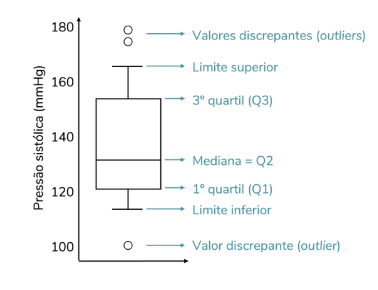

In [37]:
#boxplot usando seaborn


In [38]:
#boxplot usando plotly

In [39]:
#boxplot da idade, por sexo, usando seaborn


In [40]:
#boxplot da idade, por sexo, usando plotly


## 8.2) Dados Categóricos

In [41]:
#Grafico de contagem, por raça, no seaborn


In [42]:
#Grafico de contagem, por raça, no plotly

# cria data frame de contagem


#criacao do grafico


#9) Tratando Outliers

→ Outliers são valores que fogem muito do padrão da maioria dos dados.

→ Eles podem ser causados por erros de digitação, problemas de medição ou até representar casos reais extremos.

→ Identificar e tratar outliers é importante porque eles podem distorcer análises estatísticas e visuais, como média, desvio padrão e gráficos.

→ Algumas estratégias comuns são:

- Análise visual (gráficos como boxplot e histogramas)
- Regras estatísticas (como usar o intervalo interquartil (IQR))

→ Como tratar outliers?
- Remover os outliers (quando são claramente erros);
- Corrigir valores com base em outras variáveis (se souber o valor real esperado);
- Manter, se forem reais e importantes para a análise.

OBS: um valor fora do padrão nem sempre é um erro. Avalie o contexto antes de decidir o que fazer com ele.

In [44]:
#exemplo de remoção de idades muito avançadas


In [45]:
# Verificar novo shape da tabela


#10) Salvando o DataFrame

→ Depois de tratar e organizar os dados, podemos querer salvar a nova versão da base.

→ Para isso, usamos o método .to_csv() para salvar em formato .csv:

- O argumento index=False evita que o índice do DataFrame vire uma coluna no arquivo.
- No Colab, o arquivo salvo fica acessível na lateral (em “Arquivos”) e pode ser baixado manualmente.
- Também é possível salvar direto no Google Drive, usando o caminho completo da pasta:

In [ ]:
import os

#Salvar DataFrame
path_to_save = "/content/drive/MyDrive/ML_2026/dados_tuberculose_tratado.csv"

# Criar o diretório se ele não existir
output_dir = os.path.dirname(path_to_save)
if not os.path.exists(output_dir):
    os.makedirs(output_dir)

df_filtered.to_csv(path_to_save, index = False)

# Exercício Prático
<h3>Monte uma base para a região Sul, com pessoas de idade de 40 a 100 anos, para os anos de 2018 a 2023 e responda as seguintes questões:

1) Quantas observações temos?

2) Existem valores ausentes ou duplicados?


In [46]:
#Faz uma cópia do DataFrame Original


#Cria a lista de UFs da região Sul


#Aplica o filtro da região sul, da idade e do ano de pesquisa


#Visualiza a quantidade de observações


In [47]:
#Primeiras 5 linhas da base


In [48]:
#Verificação de valores ausentes


In [49]:
#Verificação de valores duplicados


<h3> Resposta Final:

- Aplicando-se os filtros, temos ...... observações
- valores ausentes
- valores duplicados